In [44]:
import pickle
from glob import glob
import os.path as op
import pandas as pd

from functools import reduce
from operator import getitem

import matplotlib.pyplot as plt
from scipy import stats
import xcp_d
import seaborn as sns
import numpy as np

In [55]:
msmall_path = '/pscratch/sd/m/mphagen/hcp-functional-connectivity/derivatives/connectivity-matrices/MSMAll/lassoBIC_blocks'
msmall_pkls = glob(op.join(op.join(msmall_path, 'sub-*', '*.pkl')))

In [56]:
len(msmall_pkls)

96

In [57]:
sub_list = [] 

In [58]:
for file in msmall_pkls: 
    sub_list.append(op.basename(file).split('_')[0]) 


In [59]:
node_list = [f"node_{ii}" for ii in range(0,100)] 
fold_list = [f"fold_{ii}" for ii in range(0,2)] 
iterables = [fold_list, node_list]

In [69]:
with open(msmall_pkls[1], 'rb') as l:
    result_dict = pickle.load(l)

In [71]:
result_dict.keys()

dict_keys(['full_fc_matrix', 'fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4'])

In [80]:
index = pd.MultiIndex.from_product(iterables, names=["fold", "node"])
temp_df = pd.DataFrame(index=index, columns=sub_list, dtype=float)
r2_df = temp_df
for file in msmall_pkls: 
    r2_df = extract_r2(file, r2_df) 


# r2_df.to_csv('msmall_r2_2025-12-08.csv') 

In [77]:
index = pd.MultiIndex.from_product(iterables, names=["fold", "node"])
temp_df = pd.DataFrame(index=index, columns=sub_list, dtype=float)
r2_df_train = temp_df
for file in msmall_pkls: 
    r2_df_train = extract_r2_train(file, r2_df_train) 


# r2_df.to_csv('msmall_r2_2025-12-08.csv') 

In [67]:
len(msmall_pkls)

96

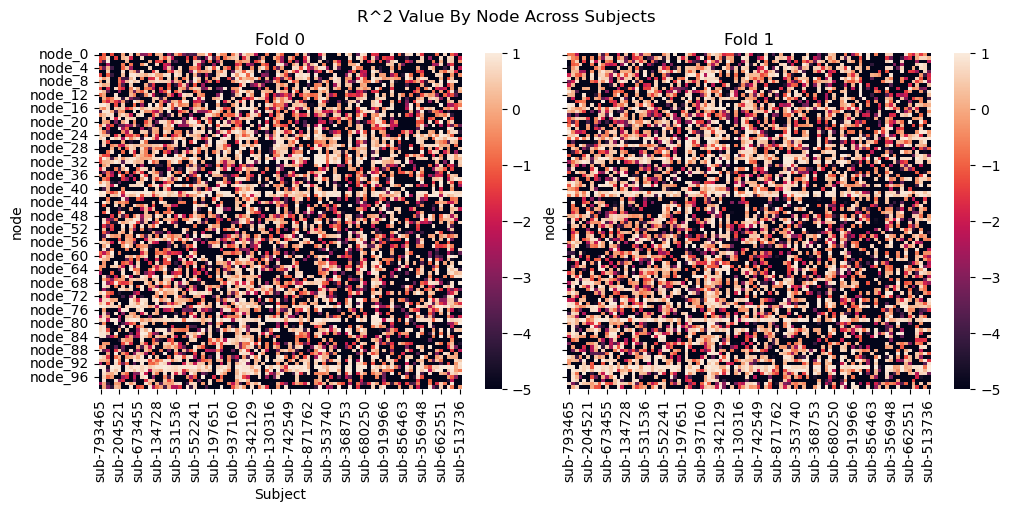

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharex=True, sharey=True, layout="constrained") 
sns.heatmap(ax=ax[0], data=r2_df.loc['fold_0'], vmax=1, vmin=-5)
ax[0].set_title("Fold 0") 
ax[1].set_title("Fold 1") 
# ax[2].set_title("Fold 2") 
# ax[3].set_title("Fold 3") 
# ax[4].set_title("Fold 4") 

sns.heatmap(ax=ax[1], data=r2_df.loc['fold_1'], vmax=1, vmin=-5)
# sns.heatmap(ax=ax[2], data=r2_df.loc['fold_2'], vmax=1, vmin=-5)
# sns.heatmap(ax=ax[3], data=r2_df.loc['fold_3'], vmax=1, vmin=-5)
# sns.heatmap(ax=ax[4], data=r2_df.loc['fold_4'], vmax=1, vmin=-5)

# ax[4].set_title("Fold 4") 
ax[0].set_xlabel("Subject") 
fig.suptitle("R^2 Value By Node Across Subjects") 
plt.savefig('r2_byfold.png') 

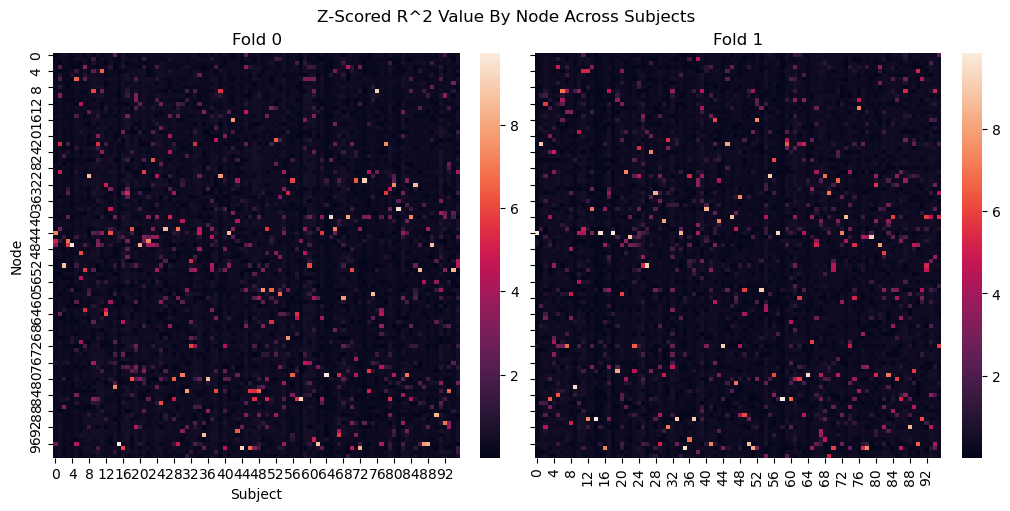

In [43]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), sharex=True, sharey=True, layout="constrained") 
sns.heatmap(ax=ax[0], data=np.abs(stats.zscore(r2_df.loc['fold_0'])))


sns.heatmap(ax=ax[1], data=np.abs(stats.zscore(r2_df.loc['fold_1'])))
# sns.heatmap(ax=ax[2], data=np.abs(stats.zscore(r2_df.loc['fold_2'])))
# sns.heatmap(ax=ax[3], data=np.abs(stats.zscore(r2_df.loc['fold_3'])))
# sns.heatmap(ax=ax[4], data=np.abs(stats.zscore(r2_df.loc['fold_4'])))
ax[0].set_title("Fold 0") 
ax[1].set_title("Fold 1") 
# ax[2].set_title("Fold 2") 
# ax[3].set_title("Fold 3") 
# ax[4].set_title("Fold 4") 

ax[0].set_xlabel("Subject") 
ax[0].set_ylabel("Node") 

fig.suptitle("Z-Scored R^2 Value By Node Across Subjects") 
plt.savefig('r2_byfold.png') 

In [19]:
outliers = [] 

In [20]:
mean_df = r2_df.loc[f'fold_0'].mean(axis=1)
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index) 

In [21]:
mean_df = r2_df.loc[f'fold_1'].mean(axis=1)
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index)

In [22]:
mean_df = r2_df.loc[f'fold_2'].mean(axis=1)
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index)

In [23]:
mean_df = r2_df.loc[f'fold_3'].mean(axis=1)
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index) 

In [24]:
mean_df = r2_df.loc[f'fold_4'].mean(axis=1)
outliers.extend(mean_df[np.abs(stats.zscore(mean_df) ) > 2].index)

In [25]:
#datalad clone atlaspack.git
#datalad get 4156.dseg

In [26]:
 from collections import Counter

In [27]:
Counter(outliers)

Counter({'node_30': 4,
         'node_31': 4,
         'node_78': 4,
         'node_79': 4,
         'node_0': 4,
         'node_41': 2,
         'node_50': 2,
         'node_93': 2,
         'node_10': 1,
         'node_18': 1,
         'node_36': 1,
         'node_76': 1,
         'node_86': 1})

In [28]:
atlas_file = '/global/u1/m/mphagen/AtlasPack/atlas-4S156Parcels_dseg.tsv' 

In [35]:
atlas_df.iloc[[0, 10, 18, 30, 31, 36, 41, 50, 76, 78, 79, 86, 93]][['label', 'index', 'label_7network']].to_csv('msmall_problematic_nodes.tsv', sep='\t') 

In [34]:
atlas_df = pd.read_csv(atlas_file, sep='\t')

In [ ]:
import nibabel as nb

In [ ]:
def read_ts(file, n_trs, n_rois):
    if len(ts_files) > 1: 
        
        time_series = np.loadtxt(file, delimiter='\t').reshape(-1, n_rois)
    
    else: 
        time_series = np.loadtxt(file, delimiter='\t').reshape(n_trs, n_rois)

        
    return(time_series)

In [ ]:
ts_files

In [ ]:
cifti = nb.load(ts_files)
cifti_data = cifti.get_fdata(dtype=np.float32)